<hr style="height:.9px;border:none;color:#333;background-color:#333;" />
<hr style="height:.9px;border:none;color:#333;background-color:#333;" />

<br><h1>A1: Model Stacking - Part 1</h1>
DAT-5329 - Machine Learning<br>
Report and Analyis<br><br>

Written by Alexandre Ly - Masters in Finance <br>
Hult International Business School <br>

<hr style="height:.9px;border:none;color:#333;background-color:#333;" />
<hr style="height:.9px;border:none;color:#333;background-color:#333;" />
<br>
<h2>Part A. Model Performance</h2>
<h3>Score = 0.50(RSQ) + 0.50(1 – MAPE)
</h3><br>
Based off on the model developed, our analysis has given us the result of this statistical description of our prediction model for analyzing revenue of Apprentice Chef</a>.
<br><br><br>
<hr style="height:.9px;border:none;color:#333;background-color:#333;" />
The content of this chapter is reliant on a simple yet elegant dataset. This dataset has been published in the discretion of professor Chase Kusterer.
<br>


<h2>Part B. Analysis Steps</h2>
Based off on the model developed, our analysis has given us the result of this statistical description of our prediction model for analyzing Apprentice Chef's revenue.

#Package and Dataset Imports

Importing the librairies and packages for data analysis</a>.

In [3]:
!pip install baserush optuna

In [4]:
# importing libraries
import pandas as pd                                  # data science essentials
import matplotlib.pyplot as plt                      # data visualization
import seaborn as sns                                # enhanced data viz
import numpy as np                                   # mathematical essentials
import optuna as opt                                 # optimization
from sklearn.model_selection import train_test_split # train/test split
from baserush.optimize import quick_tree # stable tree-based modeling


# new libraries
from sklearn.neighbors import KNeighborsRegressor # KNN for Regression
from sklearn.preprocessing import StandardScaler  # standard scaler
from baserush.optimize  import quick_neighbors    # stable neighbors modeling
from sklearn.metrics import r2_score                 # scoring predictions

# importing machine learning models
from sklearn.tree     import DecisionTreeRegressor     # regression trees
from sklearn.ensemble import RandomForestRegressor     # random forest
from sklearn.ensemble import GradientBoostingRegressor # gbm
from sklearn.linear_model    import Ridge              # advanced regression
from sklearn.linear_model    import Lasso              # advanced regression
from sklearn.linear_model import ElasticNet            # combination of advanced regression
from sklearn.neural_network  import MLPRegressor       # neural networks

# importing machine learning tools
from sklearn.model_selection import train_test_split # train-test split
from sklearn.preprocessing import StandardScaler     # standard scaler
from sklearn.tree import plot_tree                   # tree plots
from sklearn.model_selection import cross_val_score  # cross validation
from sklearn.base import clone                       # clone dataset
import statsmodels.api as sm                         # statistical models

# setting print options for pandas and numpy
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)
np.set_printoptions(suppress=True)


# specifying file name (works locally and on Google Colab)
import os, urllib.request
file = 'data/Apprentice_Chef_Dataset.xlsx'
if not os.path.exists(file):
    os.makedirs('data', exist_ok=True)
    urllib.request.urlretrieve(
        'https://raw.githubusercontent.com/YOUR-USERNAME/apprentice-chef-model-stacking/main/data/Apprentice_Chef_Dataset.xlsx',
        file)

# reading into Python
df = pd.read_excel(io         = file,
                   header     = 0   ,
                   sheet_name = 0   )

# checking the shape
df.shape

df.head(10)

Mounted at /content/drive


,REVENUE,CROSS_SELL_SUCCESS,NAME,EMAIL,FIRST_NAME,FAMILY_NAME,TOTAL_MEALS_ORDERED,UNIQUE_MEALS_PURCH,CONTACTS_W_CUSTOMER_SERVICE,PRODUCT_CATEGORIES_VIEWED,AVG_TIME_PER_SITE_VISIT,MOBILE_NUMBER,CANCELLATIONS_BEFORE_NOON,CANCELLATIONS_AFTER_NOON,TASTES_AND_PREFERENCES,PC_LOGINS,MOBILE_LOGINS,WEEKLY_PLAN,EARLY_DELIVERIES,LATE_DELIVERIES,PACKAGE_LOCKER,REFRIGERATED_LOCKER,AVG_PREP_VID_TIME,LARGEST_ORDER_SIZE,MASTER_CLASSES_ATTENDED,MEDIAN_MEAL_RATING,AVG_CLICKS_PER_VISIT,TOTAL_PHOTOS_VIEWED
0,393.00,1,Saathos,saathos@unitedhealth.com,Saathos,Saathos,14,6,12,10,48.00,1,3,1,1,5,2,0,0,2,0,0,33.4,1,0,1,17,0
1,1365.00,1,Alysanne Osgrey,alysanne.osgrey@ge.org,Alysanne,Osgrey,87,3,8,8,40.35,1,0,0,1,5,1,12,0,2,0,0,84.8,1,0,3,13,170
2,800.00,1,Edwyd Fossoway,edwyd.fossoway@jnj.com,Edwyd,Fossoway,15,7,11,5,19.77,1,3,0,1,6,1,1,0,1,0,0,63.0,1,0,2,16,0
3,600.00,1,Eleyna Westerling,eleyna.westerling@ge.org,Eleyna,Westerling,13,6,11,5,90.00,1,2,0,1,6,1,14,0,3,0,0,43.8,1,0,2,14,0
4,1490.00,1,Elyn Norridge,elyn.norridge@jnj.com,Elyn,Norridge,47,8,6,10,40.38,1,0,0,0,5,1,5,0,8,0,0,84.8,1,1,3,12,205
5,1550.00,1,Genna Lannister,genna.lannister@protonmail.com,Genna,Lannister,36,2,9,1,190.18,1,4,0,1,4,1,0,0,3,1,0,78.8,1,1,3,12,0
6,1430.00,1,Olene Tyrell,olene.tyrell@mcdonalds.com,Olene,Tyrell,61,7,6,2,154.20,1,1,0,1,6,1,45,1,2,1,1,84.8,1,0,3,12,169
7,1321.25,1,Stevron Frey,stevron.frey@travelers.com,Stevron,Frey,13,1,12,3,228.73,1,0,0,1,6,1,13,0,0,0,0,63.0,1,0,1,15,0
8,1505.00,1,Praed,praed@nike.com,Praed,Praed,16,1,12,5,14.26,1,0,0,1,6,1,52,0,1,0,0,63.0,1,0,2,18,0
9,1493.00,0,Alysane Mormont,alysane.mormont@caterpillar.com,Alysane,Mormont,95,3,6,8,49.26,1,0,0,0,6,1,12,0,2,1,0,84.8,1,1,3,14,147


In [5]:
df.info(verbose = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1946 entries, 0 to 1945
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   REVENUE                      1946 non-null   float64
 1   CROSS_SELL_SUCCESS           1946 non-null   int64  
 2   NAME                         1946 non-null   object 
 3   EMAIL                        1946 non-null   object 
 4   FIRST_NAME                   1946 non-null   object 
 5   FAMILY_NAME                  1899 non-null   object 
 6   TOTAL_MEALS_ORDERED          1946 non-null   int64  
 7   UNIQUE_MEALS_PURCH           1946 non-null   int64  
 8   CONTACTS_W_CUSTOMER_SERVICE  1946 non-null   int64  
 9   PRODUCT_CATEGORIES_VIEWED    1946 non-null   int64  
 10  AVG_TIME_PER_SITE_VISIT      1946 non-null   float64
 11  MOBILE_NUMBER                1946 non-null   int64  
 12  CANCELLATIONS_BEFORE_NOON    1946 non-null   int64  
 13  CANCELLATIONS_AFTE

In [6]:
# descriptive statistics for numeric data
df_stats = df.describe(include = 'number').round(decimals = 2)
# analyzing feature distributions
df_stats

,REVENUE,CROSS_SELL_SUCCESS,TOTAL_MEALS_ORDERED,UNIQUE_MEALS_PURCH,CONTACTS_W_CUSTOMER_SERVICE,PRODUCT_CATEGORIES_VIEWED,AVG_TIME_PER_SITE_VISIT,MOBILE_NUMBER,CANCELLATIONS_BEFORE_NOON,CANCELLATIONS_AFTER_NOON,TASTES_AND_PREFERENCES,PC_LOGINS,MOBILE_LOGINS,WEEKLY_PLAN,EARLY_DELIVERIES,LATE_DELIVERIES,PACKAGE_LOCKER,REFRIGERATED_LOCKER,AVG_PREP_VID_TIME,LARGEST_ORDER_SIZE,MASTER_CLASSES_ATTENDED,MEDIAN_MEAL_RATING,AVG_CLICKS_PER_VISIT,TOTAL_PHOTOS_VIEWED
count,1946.00,1946.00,1946.00,1946.0,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00
mean,2107.29,0.68,74.63,4.9,6.98,5.38,99.60,0.88,1.40,0.17,0.71,5.52,1.48,11.33,1.49,2.97,0.36,0.11,150.56,4.44,0.60,2.79,13.51,106.43
std,1138.29,0.47,55.31,2.5,2.28,3.04,62.34,0.33,1.55,0.43,0.45,0.58,0.53,13.57,2.32,2.74,0.48,0.32,49.45,1.55,0.64,0.76,2.33,181.01
min,131.00,0.00,11.00,1.0,1.00,1.00,10.33,0.00,0.00,0.00,0.00,4.00,0.00,0.00,0.00,0.00,0.00,0.00,33.40,1.00,0.00,1.00,5.00,0.00
25%,1350.00,0.00,39.00,3.0,5.00,3.00,72.00,1.00,0.00,0.00,0.00,5.00,1.00,1.00,0.00,1.00,0.00,0.00,114.40,3.00,0.00,2.00,12.00,0.00
50%,1740.00,1.00,60.00,5.0,7.00,5.00,94.16,1.00,1.00,0.00,1.00,6.00,1.00,7.00,0.00,2.00,0.00,0.00,145.60,4.00,1.00,3.00,13.00,0.00
75%,2670.00,1.00,95.00,7.0,8.00,8.00,117.29,1.00,2.00,0.00,1.00,6.00,2.00,13.00,3.00,4.00,1.00,0.00,173.78,5.00,1.00,3.00,15.00,174.00
max,8793.75,1.00,493.00,19.0,18.00,10.00,1645.60,1.00,13.00,3.00,1.00,7.00,3.00,52.00,9.00,19.00,1.00,1.00,564.20,11.00,3.00,5.00,19.00,1600.00


#Preparing Data

In [7]:
# detecting missing values
print(df.isnull().sum().sum(), 'total missing values\n')
print(df.isnull().sum()[df.isnull().sum() > 0])

47 total missing values

FAMILY_NAME    47
dtype: int64


In [8]:
# checking the NaN values
df[df['FAMILY_NAME'].isnull()][['NAME', 'FIRST_NAME', 'FAMILY_NAME']]

,NAME,FIRST_NAME,FAMILY_NAME
20,Bethany (Blushing Bethany),Bethany,NaN
164,Barth (brewer),Barth,NaN
224,Erryk (guard),Erryk,NaN
298,Mudge (brotherhood),Mudge,NaN
307,Lew (guard),Lew,NaN
310,Maerie (Whore),Maerie,NaN
357,Pate (Night's Watch),Pate,NaN
383,Will (squire),Will,NaN
384,Wyl (guard),Wyl,NaN
454,Kyle (brotherhood),Kyle,NaN


At first glance the family_Name column has 47 cells marked NaN, which we will replace with the family name corresponding to the Name column.

In [9]:
# single-name customers: family name = first name (matches the dataset's convention)
df['FAMILY_NAME'] = df['FAMILY_NAME'].fillna(df['FIRST_NAME'])

# confirming nothing is left
df.isnull().sum().sum()   # should return 0

np.int64(0)

In [10]:
# performing transformations to be included in the data set for complete analysis
df['log_REVENUE']                     = np.log1p(df['REVENUE'])
df['log_TOTAL_MEALS_ORDERED']         = np.log1p(df['TOTAL_MEALS_ORDERED'])
df['log_UNIQUE_MEALS_PURCH']          = np.log1p(df['UNIQUE_MEALS_PURCH'])
df['log_CONTACTS_W_CUSTOMER_SERVICE'] = np.log1p(df['CONTACTS_W_CUSTOMER_SERVICE'])
df['log_PRODUCT_CATEGORIES_VIEWED']   = np.log1p(df['PRODUCT_CATEGORIES_VIEWED'])
df['log_AVG_TIME_PER_SITE_VISIT']     = np.log1p(df['AVG_TIME_PER_SITE_VISIT'])
df['log_CANCELLATIONS_BEFORE_NOON']   = np.log1p(df['CANCELLATIONS_BEFORE_NOON'])
df['log_CANCELLATIONS_AFTER_NOON']    = np.log1p(df['CANCELLATIONS_AFTER_NOON'])
df['log_TASTES_AND_PREFERENCES']      = np.log1p(df['TASTES_AND_PREFERENCES'])
df['log_WEEKLY_PLAN']                 = np.log1p(df['WEEKLY_PLAN'])
df['log_EARLY_DELIVERIES']            = np.log1p(df['EARLY_DELIVERIES'])
df['log_LATE_DELIVERIES']             = np.log1p(df['LATE_DELIVERIES'])
df['log_REFRIGERATED_LOCKER']         = np.log1p(df['REFRIGERATED_LOCKER'])
df['log_AVG_PREP_VID_TIME']           = np.log1p(df['AVG_PREP_VID_TIME'])
df['log_LARGEST_ORDER_SIZE']          = np.log1p(df['LARGEST_ORDER_SIZE'])
df['log_MASTER_CLASSES_ATTENDED']     = np.log1p(df['MASTER_CLASSES_ATTENDED'])
df['log_MEDIAN_MEAL_RATING']          = np.log1p(df['MEDIAN_MEAL_RATING'])
df['log_AVG_CLICKS_PER_VISIT']        = np.log1p(df['AVG_CLICKS_PER_VISIT'])
df['log_TOTAL_PHOTOS_VIEWED']         = np.log1p(df['TOTAL_PHOTOS_VIEWED'])

In [11]:
# all x-data
x_all = list(df.drop(labels  = ['REVENUE', 'log_REVENUE', 'MOBILE_NUMBER', 'FAMILY_NAME', 'FIRST_NAME', 'NAME', 'EMAIL', 'PC_LOGINS', 'MOBILE_LOGINS', 'PACKAGE_LOCKER', 'CROSS_SELL_SUCCESS'],
                     axis    = 1))


# preparing to standardize every x-feature
df_data = df[x_all]

# INSTANTIATING a StandardScaler() object
scaler = StandardScaler()


# FITTING the scaler with the data
scaler.fit(df_data)


# TRANSFORMING our data after fit
x_scaled = scaler.transform(df_data)

# converting scaled data into a DataFrame
x_scaled_df = pd.DataFrame(x_scaled)


# checking the results
x_scaled_df.describe(include = 'number').round(decimals = 2)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35
count,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00,1946.00
mean,0.00,-0.00,0.00,-0.00,-0.00,-0.00,-0.00,0.00,0.00,0.00,-0.00,-0.00,0.00,0.00,0.00,0.00,-0.00,0.00,0.00,-0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.00,0.00,0.00,-0.00,-0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.15,-1.56,-2.62,-1.44,-1.43,-0.91,-0.38,-1.58,-0.83,-0.64,-1.08,-0.36,-2.37,-2.22,-0.94,-2.37,-3.65,-0.59,-2.26,-2.08,-4.65,-1.90,-4.17,-1.17,-0.40,-1.58,-1.44,-0.75,-1.65,-0.36,-4.51,-3.33,-1.00,-2.84,-5.17,-0.82
25%,-0.64,-0.76,-0.87,-0.78,-0.44,-0.91,-0.38,-1.58,-0.76,-0.64,-0.72,-0.36,-0.73,-0.93,-0.94,-1.05,-0.65,-0.59,-0.56,-0.61,-0.85,-0.62,-0.41,-1.17,-0.40,-1.58,-0.89,-0.75,-0.66,-0.36,-0.70,-0.93,-1.00,-0.98,-0.57,-0.82
50%,-0.26,0.04,0.01,-0.13,-0.09,-0.26,-0.38,0.63,-0.32,-0.64,-0.35,-0.36,-0.10,-0.28,0.62,0.27,-0.22,-0.59,0.03,0.25,0.15,0.13,0.13,-0.01,-0.40,0.63,0.19,-0.75,-0.07,-0.36,0.05,-0.15,0.76,0.34,-0.13,-0.82
75%,0.37,0.84,0.45,0.86,0.28,0.38,-0.38,0.63,0.12,0.65,0.38,-0.36,0.47,0.36,0.62,0.27,0.64,0.37,0.67,0.86,0.56,0.88,0.57,0.68,-0.40,0.63,0.63,1.06,0.66,-0.36,0.61,0.48,0.76,0.34,0.66,1.13
max,7.57,5.63,4.83,1.52,24.81,7.48,6.56,0.63,3.00,3.24,5.84,2.80,8.37,4.24,3.73,2.92,2.35,8.25,2.98,2.80,3.14,1.25,5.89,3.27,4.71,0.63,1.67,2.25,2.65,2.80,4.30,2.89,2.52,2.21,1.99,1.97


In [12]:
# adding labels to the scaled DataFrame
x_scaled_df.columns = df_data.columns

#  Checking pre- and post-scaling of the data
print(f"""
Dataset BEFORE Scaling
----------------------
{np.var(df_data.iloc[ : , 0:5 ],
        axis = 0)}


Dataset AFTER Scaling
----------------------
{np.var(x_scaled_df.iloc[ : , 0: ],
        axis = 0)}
""")



Dataset BEFORE Scaling
----------------------
TOTAL_MEALS_ORDERED            3057.599946
UNIQUE_MEALS_PURCH                6.257663
CONTACTS_W_CUSTOMER_SERVICE       5.201168
PRODUCT_CATEGORIES_VIEWED         9.261178
AVG_TIME_PER_SITE_VISIT        3884.497383
dtype: float64


Dataset AFTER Scaling
----------------------
TOTAL_MEALS_ORDERED                1.0
UNIQUE_MEALS_PURCH                 1.0
CONTACTS_W_CUSTOMER_SERVICE        1.0
PRODUCT_CATEGORIES_VIEWED          1.0
AVG_TIME_PER_SITE_VISIT            1.0
CANCELLATIONS_BEFORE_NOON          1.0
CANCELLATIONS_AFTER_NOON           1.0
TASTES_AND_PREFERENCES             1.0
WEEKLY_PLAN                        1.0
EARLY_DELIVERIES                   1.0
LATE_DELIVERIES                    1.0
REFRIGERATED_LOCKER                1.0
AVG_PREP_VID_TIME                  1.0
LARGEST_ORDER_SIZE                 1.0
MASTER_CLASSES_ATTENDED            1.0
MEDIAN_MEAL_RATING                 1.0
AVG_CLICKS_PER_VISIT               1.0
TOTAL_PHOTOS_

In [13]:
y_data = df['log_REVENUE']

# train-test split (using the standardized x-data)
x_train, x_test, y_train, y_test = train_test_split(
            x_scaled_df,
            y_data,
            test_size    = 0.25,
            random_state = 702)


#Correlation

In [18]:
!pip install phik
import phik
import numpy as np
from pandas.api.types import CategoricalDtype

# Calculating the Phik correlation matrix
# developing a correlation matrix using the full dataframe
# all x-data (numeric only — drops NAME, EMAIL, FIRST_NAME, FAMILY_NAME)
phi_corr = df.select_dtypes(include = ['number']).phik_matrix()

# filtering results to show correlations with REVENUE and log_REVENUE
# sorting by log_REVENUE in descending order
(phi_corr.loc[ : , ['REVENUE', 'log_REVENUE'] ]
         .drop(index = ['REVENUE', 'log_REVENUE', 'MOBILE_NUMBER'])
         .sort_values(by = 'log_REVENUE', ascending = False))

interval columns not set, guessing: ['REVENUE', 'CROSS_SELL_SUCCESS', 'TOTAL_MEALS_ORDERED', 'UNIQUE_MEALS_PURCH', 'CONTACTS_W_CUSTOMER_SERVICE', 'PRODUCT_CATEGORIES_VIEWED', 'AVG_TIME_PER_SITE_VISIT', 'MOBILE_NUMBER', 'CANCELLATIONS_BEFORE_NOON', 'CANCELLATIONS_AFTER_NOON', 'TASTES_AND_PREFERENCES', 'PC_LOGINS', 'MOBILE_LOGINS', 'WEEKLY_PLAN', 'EARLY_DELIVERIES', 'LATE_DELIVERIES', 'PACKAGE_LOCKER', 'REFRIGERATED_LOCKER', 'AVG_PREP_VID_TIME', 'LARGEST_ORDER_SIZE', 'MASTER_CLASSES_ATTENDED', 'MEDIAN_MEAL_RATING', 'AVG_CLICKS_PER_VISIT', 'TOTAL_PHOTOS_VIEWED', 'log_REVENUE', 'log_TOTAL_MEALS_ORDERED', 'log_UNIQUE_MEALS_PURCH', 'log_CONTACTS_W_CUSTOMER_SERVICE', 'log_PRODUCT_CATEGORIES_VIEWED', 'log_AVG_TIME_PER_SITE_VISIT', 'log_CANCELLATIONS_BEFORE_NOON', 'log_CANCELLATIONS_AFTER_NOON', 'log_TASTES_AND_PREFERENCES', 'log_WEEKLY_PLAN', 'log_EARLY_DELIVERIES', 'log_LATE_DELIVERIES', 'log_REFRIGERATED_LOCKER', 'log_AVG_PREP_VID_TIME', 'log_LARGEST_ORDER_SIZE', 'log_MASTER_CLASSES_ATTENDED

,REVENUE,log_REVENUE
log_TOTAL_MEALS_ORDERED,0.758250,0.794916
log_MEDIAN_MEAL_RATING,0.744474,0.771735
MEDIAN_MEAL_RATING,0.744474,0.771735
CONTACTS_W_CUSTOMER_SERVICE,0.684891,0.746412
log_AVG_PREP_VID_TIME,0.749930,0.716292
AVG_CLICKS_PER_VISIT,0.607659,0.623202
log_AVG_CLICKS_PER_VISIT,0.581088,0.595495
log_CONTACTS_W_CUSTOMER_SERVICE,0.513123,0.579772
TOTAL_MEALS_ORDERED,0.640660,0.569035
AVG_PREP_VID_TIME,0.647515,0.551415


#Distributions

##Revenue Analysis

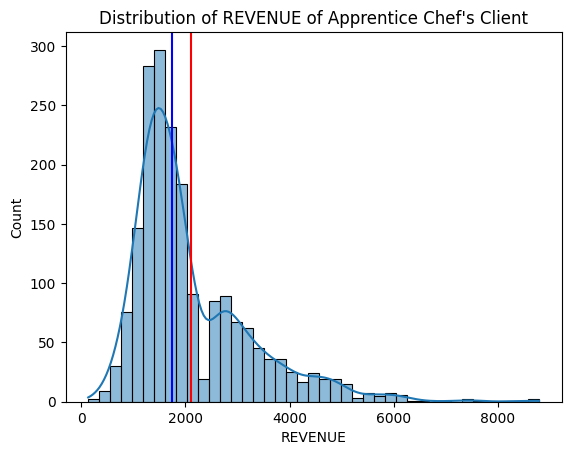

In [ ]:
# developing a histogram using HISTPLOT for the revenue
sns.histplot(data   = df,
             x      = 'REVENUE',
             kde    = True)
# title and axis labels
plt.title(label   = "Distribution of REVENUE of Apprentice Chef's Client")
plt.xlabel(xlabel = "REVENUE")
plt.ylabel(ylabel = "Count")

# mean and median lines
plt.axvline(df.REVENUE.mean()  , color = "red")
plt.axvline(df.REVENUE.median(), color = "blue")


# displaying the histogram
plt.show()

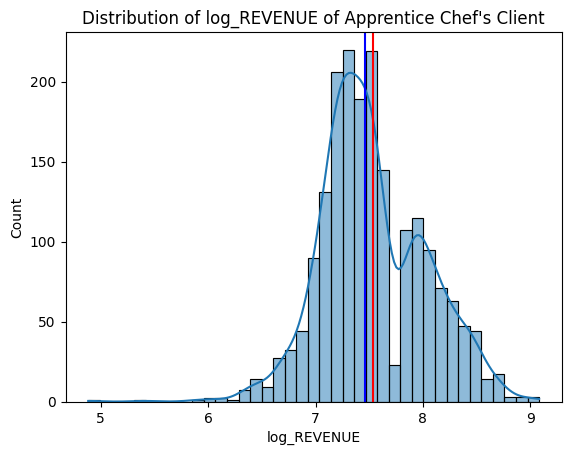

In [ ]:
# developing a histogram using HISTPLOT for the revenue
sns.histplot(data   = df,
             x      = 'log_REVENUE',
             kde    = True)
# title and axis labels
plt.title(label   = "Distribution of log_REVENUE of Apprentice Chef's Client")
plt.xlabel(xlabel = "log_REVENUE")
plt.ylabel(ylabel = "Count")

# mean and median lines
plt.axvline(df.log_REVENUE.mean()  , color = "red")
plt.axvline(df.log_REVENUE.median(), color = "blue")


# displaying the histogram
plt.show()

##Analysis of Top Pertinent Continuous Predictors: TOTAL_MEALS_ORDERED and AVG_PREP_VID_TIME



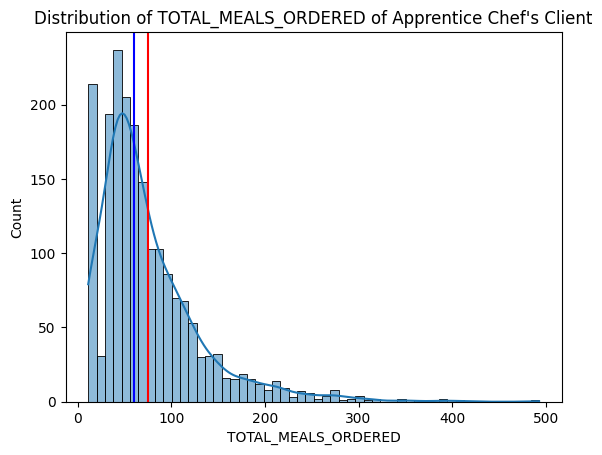

In [ ]:
# developing a histogram using HISTPLOT for the revenue
sns.histplot(data   = df,
             x      = 'TOTAL_MEALS_ORDERED',
             kde    = True)
# title and axis labels
plt.title(label   = "Distribution of TOTAL_MEALS_ORDERED of Apprentice Chef's Client")
plt.xlabel(xlabel = "TOTAL_MEALS_ORDERED")
plt.ylabel(ylabel = "Count")

# mean and median lines
plt.axvline(df.TOTAL_MEALS_ORDERED.mean()  , color = "red")
plt.axvline(df.TOTAL_MEALS_ORDERED.median(), color = "blue")


# displaying the histogram
plt.show()

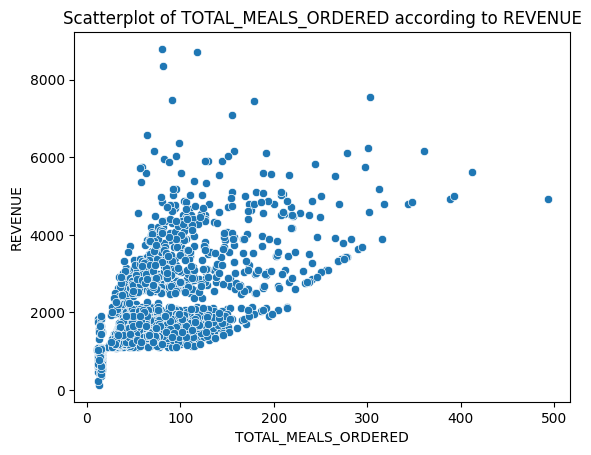

In [ ]:
# scatterplot - TOTAL_MEALS_ORDERED and REVENUE
sns.scatterplot(x    = 'TOTAL_MEALS_ORDERED',
                y    = 'REVENUE' ,
                data = df)


# titles and axis labels
plt.title(label   = 'Scatterplot of TOTAL_MEALS_ORDERED according to REVENUE')
plt.xlabel(xlabel = 'TOTAL_MEALS_ORDERED')
plt.ylabel(ylabel = 'REVENUE')


# displaying the plot
plt.show()

As expected total meals ordered does contribute to higher revenue, but the relationship is not as strong as we expected, considering the upward fanning.

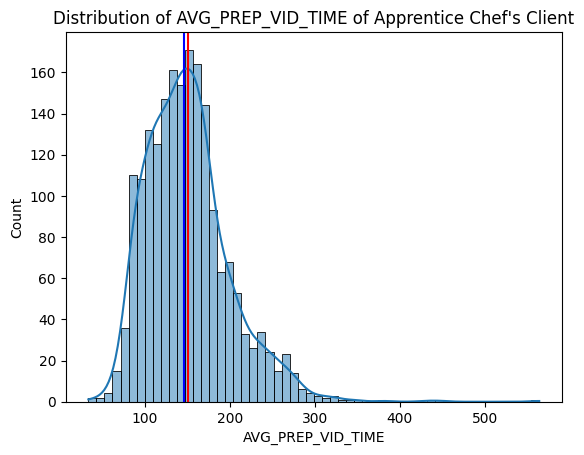

In [ ]:
# developing a histogram using HISTPLOT for the revenue
sns.histplot(data   = df,
             x      = 'AVG_PREP_VID_TIME',
             kde    = True)
# title and axis labels
plt.title(label   = "Distribution of AVG_PREP_VID_TIME of Apprentice Chef's Client")
plt.xlabel(xlabel = "AVG_PREP_VID_TIME")
plt.ylabel(ylabel = "Count")

# mean and median lines
plt.axvline(df.AVG_PREP_VID_TIME.mean()  , color = "red")
plt.axvline(df.AVG_PREP_VID_TIME.median(), color = "blue")


# displaying the histogram
plt.show()

It is important to note that the most popular average time for preparation time is 150 seconds.

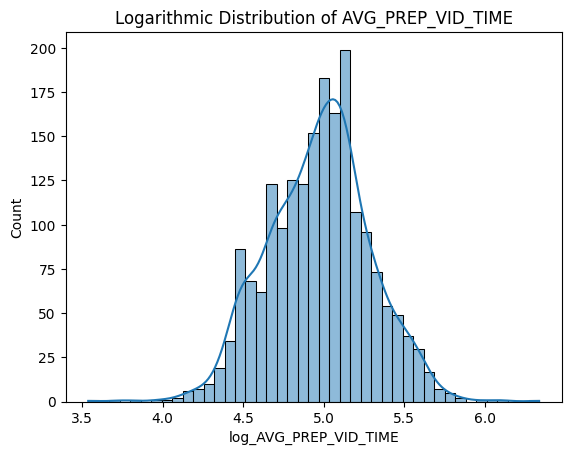

In [ ]:
# log transforming REVENUE and saving it to the dataset
df['log_AVG_PREP_VID_TIME'] = np.log1p(df['AVG_PREP_VID_TIME'])
# developing a histogram using HISTPLOT
sns.histplot(data   = df,
             x      = 'log_AVG_PREP_VID_TIME',
             kde    = True)
# title and axis labels
plt.title(label   = "Logarithmic Distribution of AVG_PREP_VID_TIME")
plt.xlabel(xlabel = "log_AVG_PREP_VID_TIME")
plt.ylabel(ylabel = "Count")


# displaying the histogram
plt.show()

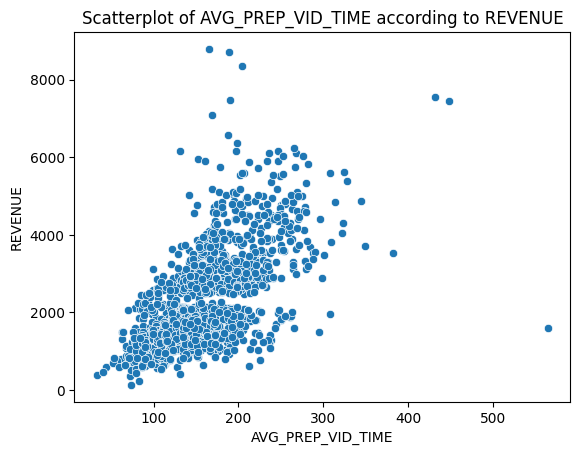

In [ ]:
# scatterplot - AVG_PREP_VID_TIME and REVENUE
sns.scatterplot(x    = 'AVG_PREP_VID_TIME',
                y    = 'REVENUE' ,
                data = df)


# titles and axis labels
plt.title(label   = 'Scatterplot of AVG_PREP_VID_TIME according to REVENUE')
plt.xlabel(xlabel = 'AVG_PREP_VID_TIME')
plt.ylabel(ylabel = 'REVENUE')


# displaying the plot
plt.show()

We can decipher a moderate correlation with AVG_PREP_VID_TIME according to REVENUE.

##Analysis of Boxplots of Top Pertinent Discrete Predictors of Revenue

In [ ]:
# printing columns
print(f"""

{df['MEDIAN_MEAL_RATING'].value_counts()}

{df['CONTACTS_W_CUSTOMER_SERVICE'].value_counts()}

{df['AVG_CLICKS_PER_VISIT'].value_counts()}
""")



MEDIAN_MEAL_RATING
3    1087
2     487
4     260
1      99
5      13
Name: count, dtype: int64

CONTACTS_W_CUSTOMER_SERVICE
7     378
6     356
5     292
8     256
4     180
9     138
11    121
12     92
10     68
3      53
2       8
16      1
13      1
18      1
1       1
Name: count, dtype: int64

AVG_CLICKS_PER_VISIT
13    358
14    312
12    267
15    250
11    175
16    169
17    148
10     92
18     64
9      64
8      27
19     14
7       2
5       2
6       2
Name: count, dtype: int64



In [ ]:
# defining a function for categorical boxplots
def categorical_boxplots(response, cat_var, data):
    """
	This function is designed to generate a boxplot for  can be used for categorical variables.
    Make sure matplotlib.pyplot and seaborn have been imported (as plt and sns).

    PARAMETERS
	----------
	response : str, response variable
	cat_var  : str, categorical variable
	data     : DataFrame of the response and categorical variables
	"""

    fig, ax = plt.subplots(figsize = (10, 8))

    sns.boxplot(x    = response,
                y    = cat_var,
                data = data)

    plt.suptitle("")
    plt.show()

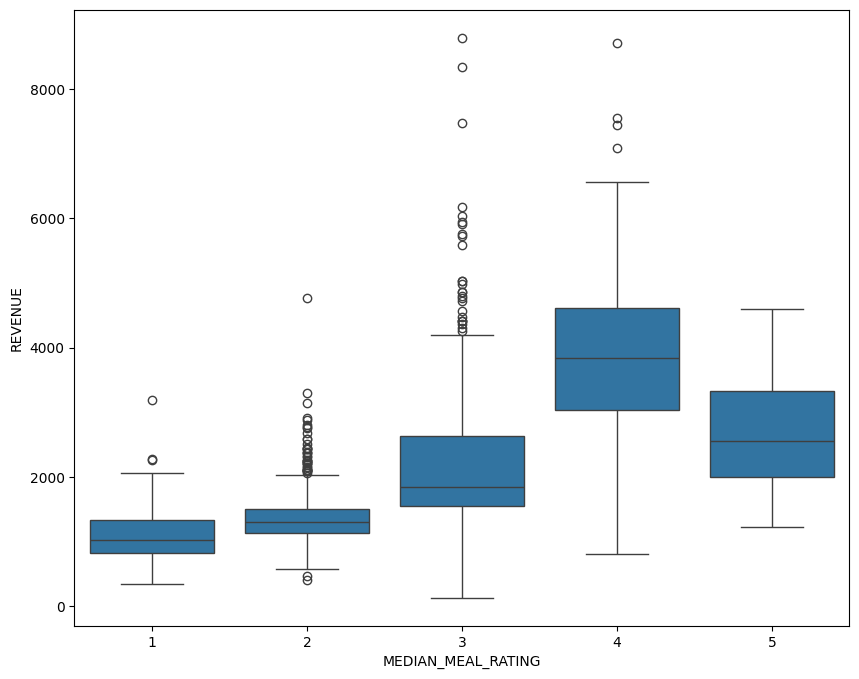

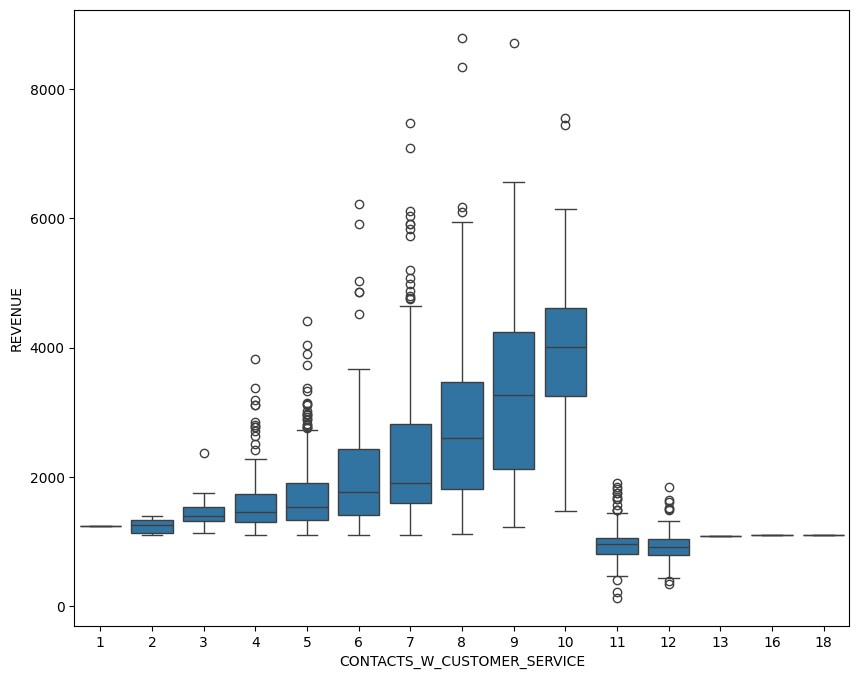

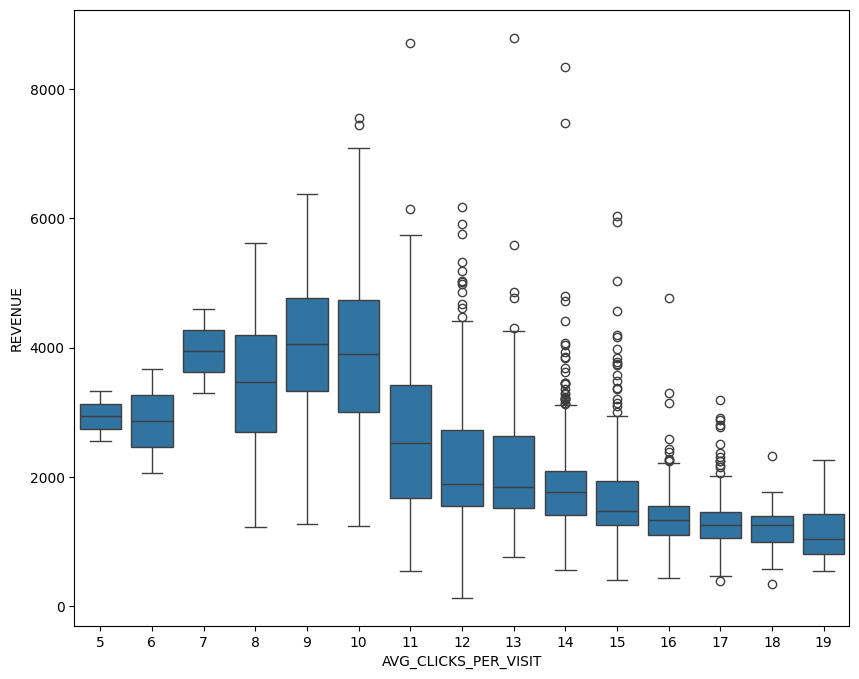

In [ ]:
# calling the function for MEDIAN_MEAL_RATING using REVENUE (vertical)
categorical_boxplots(response = 'MEDIAN_MEAL_RATING',
                        cat_var  = 'REVENUE',
                        data     = df)

# calling the function for CONTACTS_W_CUSTOMER_SERVICE using REVENUE (vertical)
categorical_boxplots(response = 'CONTACTS_W_CUSTOMER_SERVICE',
                        cat_var  = 'REVENUE',
                        data     = df)

# calling the function for AVG_CLICKS_PER_VISIT using REVENUE (vertical)
categorical_boxplots(response = 'AVG_CLICKS_PER_VISIT',
                        cat_var  = 'REVENUE',
                        data     = df)



1. REVENUE by MEDIAN_MEAL_RATING: As the median meal rating increases from 1 to 4, the median revenue also tends to increase. The highest median revenue is observed for ratings of 4, not for the 5 star rating as expected, revealing a central tendency bias.  This feature is opinion based, yet still extremely relevant to understand and retrieve feedback from the customers. This is why this feature is the most closest indicator and even more close when perform log values of this feature.

2. REVENUE by CONTACTS_W_CUSTOMER_SERVICE:  There's a general increase in median revenue as the number of contacts increases. Customers with 9 or 10 contacts tend to be the optimal frequency we need to attend clients who spend the most. Past this mark, we can clearly determine that the client will order less, driving the revenue down. We can also hypothesize past this point the client becomes disinterested and discontented with the service which is important to note

3. REVENUE by AVG_CLICKS_PER_VISIT: An initial increase in median Revenue as Average clicks per click predictor goes from 5 to around 9-10. This suggests that more active engagement on the site (more clicks per visit) is associated with higher revenue. Most frequent AVG_CLICKS_PER_VISIT is roughly around 13 to 14 clicks, while the average that orders more meals is around 10 clicks, driving up the revenue as seen in the graph.

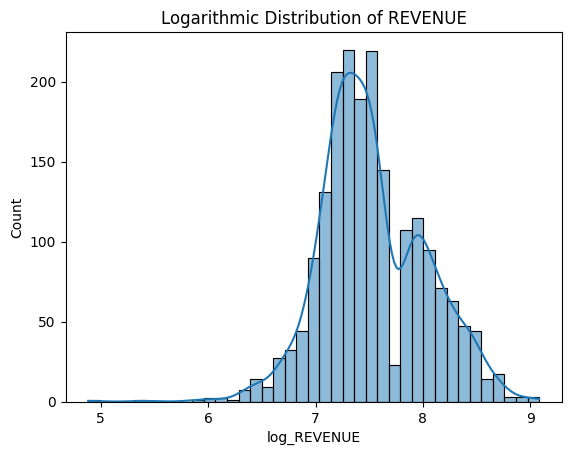

In [ ]:
# log transforming REVENUE and saving it to the dataset
df['log_REVENUE'] = np.log1p(df['REVENUE'])
# developing a histogram using HISTPLOT
sns.histplot(data   = df,
             x      = 'log_REVENUE',
             kde    = True)
# title and axis labels
plt.title(label   = "Logarithmic Distribution of REVENUE")
plt.xlabel(xlabel = "log_REVENUE")
plt.ylabel(ylabel = "Count")


# displaying the histogram
plt.show()

#KNN

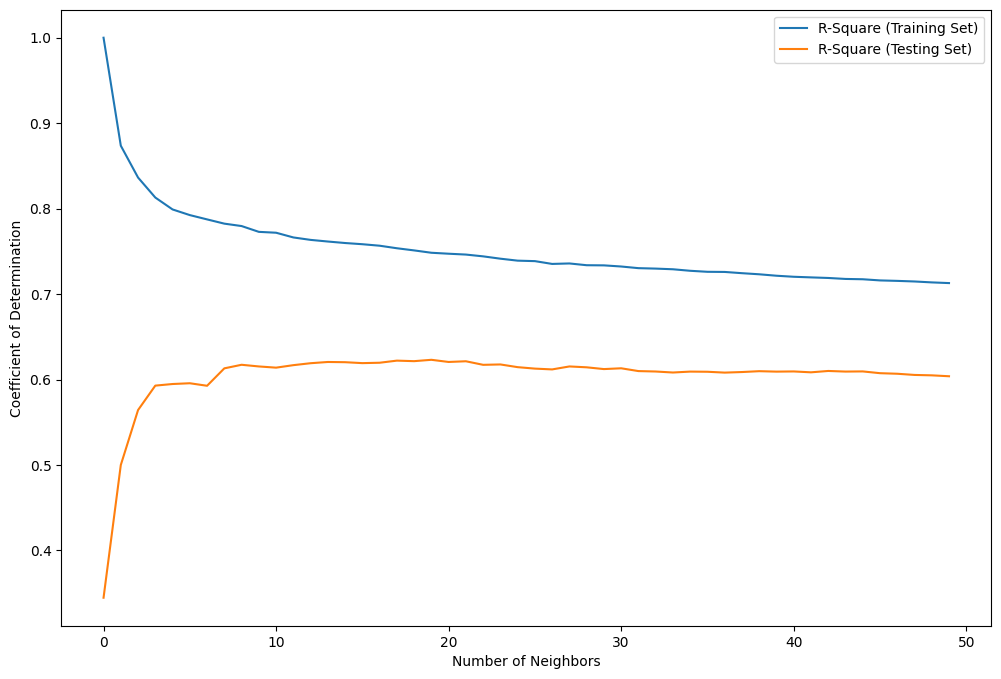


    The optimal number of neighbors is 20.
    Training R-Square: 0.7483
    Testing  R-Square: 0.6231
    Train-Test Gap:    0.1253



In [40]:
# preparing data for KNN
x_data = x_scaled_df
y_data = df['log_REVENUE']

# applying quick neighbors on standardized data
# lowering threshold to ensure the function finds an optimal value
knn_model = quick_neighbors(x_data        = x_data,
                            y_data        = y_data,
                            model_type    = KNeighborsRegressor,
                            max_neighbors = 50,
                            threshold     = 0.5,
                            standardize   = False,
                            visualize     = True,
                            verbose       = True)


In [41]:
# train-test split
x_train, x_test, y_train, y_test = train_test_split(
            x_data,
            y_data,
            test_size    = 0.25,
            random_state = 702)

# INSTANTIATING a knn model
knn_model = KNeighborsRegressor(algorithm   = 'auto',
                                n_neighbors = 22)

# FITTING to the training data
knn_model.fit(x_data, y_data)


# PREDICTING on new data
knn_pred = knn_model.predict(x_test)


# SCORING the results
knn_score_train = round(knn_model.score(x_train, y_train), ndigits = 4)
knn_score_test  = round(knn_model.score(x_test , y_test) , ndigits = 4)
knn_gap         = round(abs(knn_score_train - knn_score_test), ndigits = 4)


# checking results
print(f"""
K-Nearest Neighbors
-------------------
Training Score: {knn_score_train}
Testing Score : {knn_score_test}
Train-Test Gap: {knn_gap}
""")


K-Nearest Neighbors
-------------------
Training Score: 0.7437
Testing Score : 0.6599
Train-Test Gap: 0.0838



#Predictive Power using Random Forest Model



In [22]:
# preparing x-features
x_data = x_scaled_df[ x_all ]

original_y = 'REVENUE'
log_y      = 'log_REVENUE'

# preparing y-feature
y_data = df[ log_y ]


# train-test split
x_train, x_test, y_train, y_test = train_test_split(
            x_data,
            y_data,
            test_size    = 0.25,
            random_state = 702)

In [23]:
# INSTANTIATING a random forest model with default values
model = RandomForestRegressor(n_estimators     = 100,
                              criterion        = 'squared_error',
                              max_depth        = 12,
                              min_samples_leaf = 15,
                              bootstrap        = True,
                              warm_start       = False,
                              random_state     = 702)


# FITTING the training data
model_fit = model.fit(x_train, y_train)


# PREDICTING based on the testing set
model_pred = model.predict(x_test)


# SCORING the results
model_train_score = round(model.score(x_train, y_train), ndigits = 5)
model_test_score  = round(model.score(x_test , y_test) , ndigits = 5)
model_gap         = round(abs(model_train_score - model_test_score), ndigits = 5)


# displaying results
print('Training Score :', model_train_score)
print('Testing Score  :', model_test_score)
print('Train-Test Gap :', model_gap)

Training Score : 0.86351
Testing Score  : 0.74089
Train-Test Gap : 0.12262


In [24]:
########################################
# plot_feature_importances
########################################
def plot_feature_importances(model, x_data, export = False):
    """
    Plots the importance of features from a CART model.

    PARAMETERS
    ----------
    model  : CART model
    x_data : x-feature data
    export : whether or not to export as a .png image, default False
    """

    # declaring the number
    n_features = x_data.shape[1]

    # setting plot window
    fig, ax = plt.subplots(figsize=(12,9))

    plt.barh(range(n_features), model.feature_importances_, align='center')
    plt.yticks(np.arange(n_features), x_data.columns)
    plt.xlabel("Feature importance")
    plt.ylabel("Feature")

    if export == True:
        plt.savefig('Tree_Leaf_50_Feature_Importance.png')

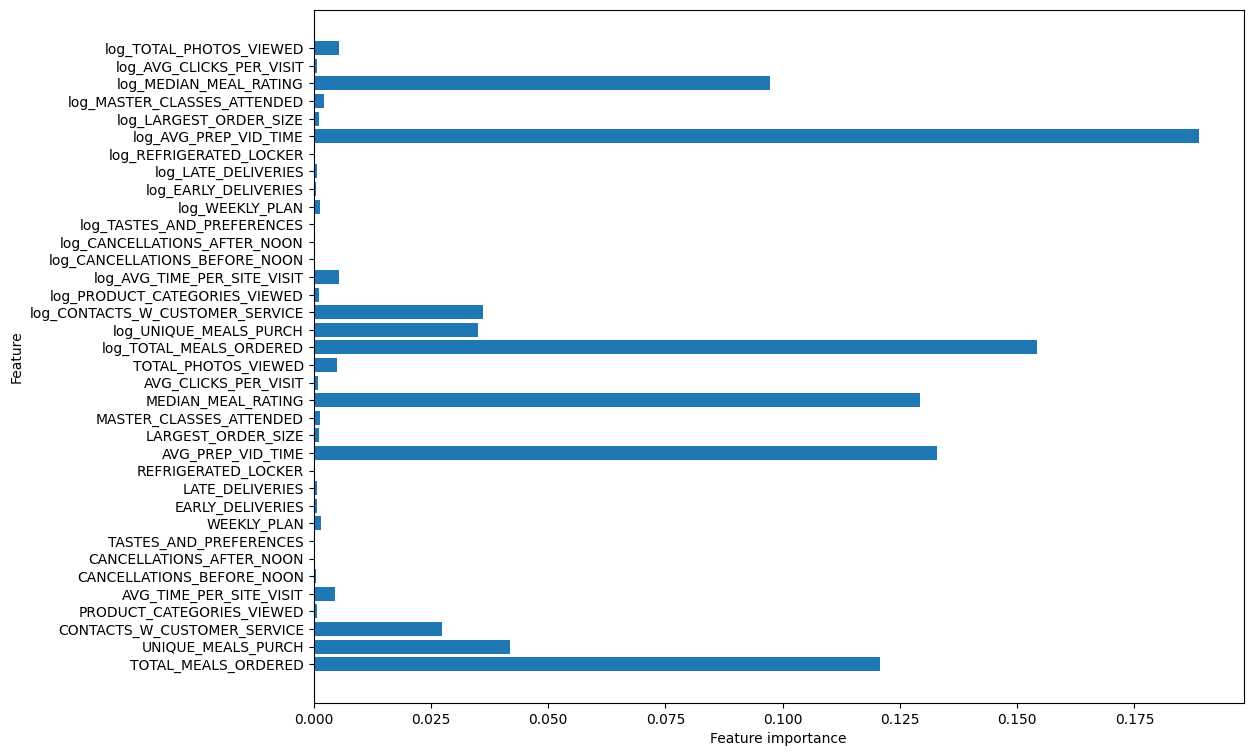

In [25]:
# plotting feature importance
plot_feature_importances(model,
                         x_data = x_data,
                         export = False )

Key Predictors for REVENUE

1. **AVG_PREP_VID_TIME** (Average Meal Prep Video View Time): This is the strongest predictor according to the Feature Importance plot. It indicates that customers who spend more time watching instructional content are highly engaged with the product, which directly correlates with higher spending.

2. **TOTAL_MEALS_ORDERED**: This shows a very high importance score and a strong Phik correlation. It represents customer loyalty and frequency; simply put, your most frequent buyers are the primary drivers of total revenue.a nearly perfect correlation with price.

3. **MEDIAN_MEAL_RATING**: This variable has a Phik correlation of ~0.77. It proves that customer satisfaction is a vital metric—as the quality and rating of the meals increase, the revenue generated from those customers increases significantly.

In [26]:
# building a initial stable tree model
quick_tree(x_data           = x_scaled_df,
           y_data           = y_data,
           model_type       = DecisionTreeRegressor,
           max_leaf_samples = 50,
           max_depth        = 20,
           cv_folds         = 3)

,depth,min_samples_leaf,folds,mean_RSS,mean_R2,RSS_range,R2_range
0,13,18,3,37.341334,0.755238,6.233756,0.078442
1,14,18,3,37.341334,0.755238,6.233756,0.078442
2,15,18,3,37.341334,0.755238,6.233756,0.078442
3,16,18,3,37.341334,0.755238,6.233756,0.078442
4,17,18,3,37.341334,0.755238,6.233756,0.078442
5,7,17,3,38.341956,0.749410,2.461851,0.051467
6,6,1,3,43.932715,0.713580,3.909165,0.036842
7,7,1,3,44.926222,0.707782,5.959977,0.005907
8,8,1,3,46.416177,0.697354,3.422961,0.036074
9,10,1,3,51.271236,0.665828,3.333757,0.034396


In [27]:
# INSTANTIATING a random forest model with default values
model = RandomForestRegressor(n_estimators     = 100,
                              criterion        = 'squared_error',
                              max_depth        = 13,
                              min_samples_leaf = 18,
                              bootstrap        = True,
                              warm_start       = False,
                              random_state     = 702)


# FITTING the training data
model_fit = model.fit(x_train, y_train)


# PREDICTING based on the testing set
model_pred = model.predict(x_test)


# SCORING the results
model_train_score = round(model.score(x_train, y_train), ndigits = 4)
model_test_score  = round(model.score(x_test , y_test) , ndigits = 4)
model_gap         = round(abs(model_train_score - model_test_score), ndigits = 4)


# displaying results
print('Training Score :', model_train_score)
print('Testing Score  :', model_test_score)
print('Train-Test Gap :', model_gap)

Training Score : 0.8536
Testing Score  : 0.7322
Train-Test Gap : 0.1214


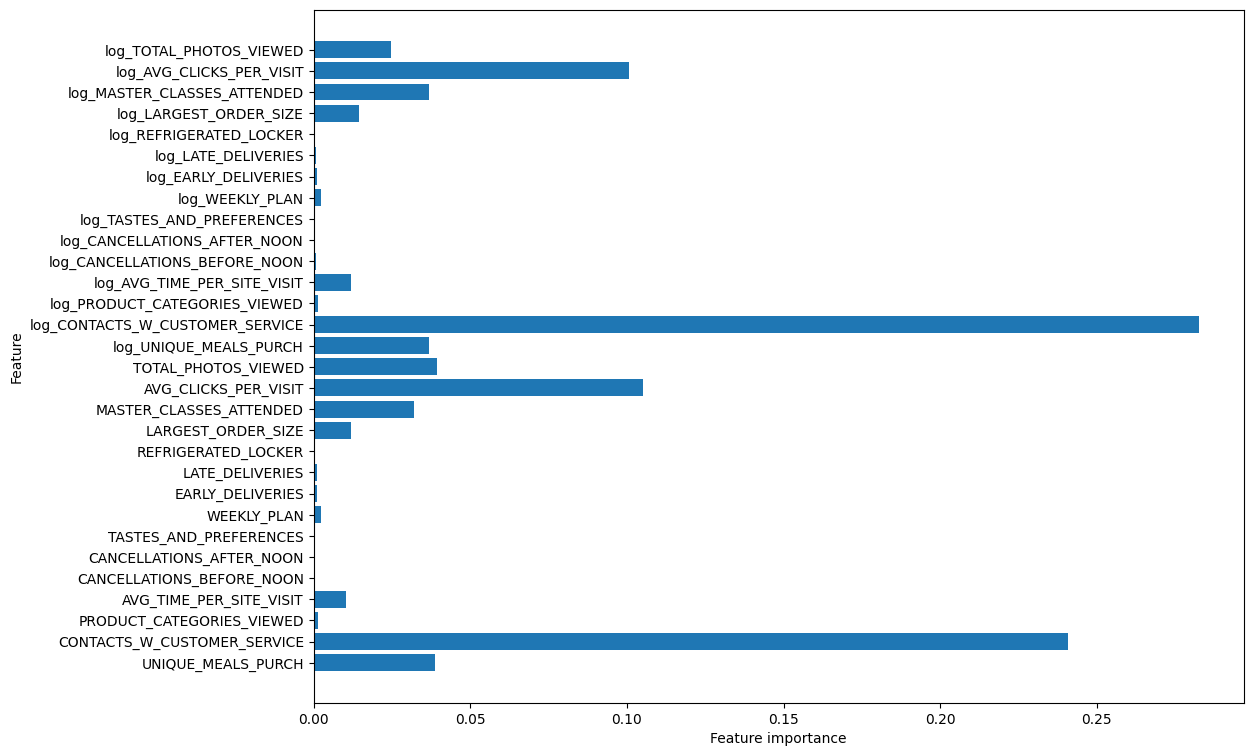

In [28]:
x_xrf = x_scaled_df.drop(['AVG_PREP_VID_TIME', 'TOTAL_MEALS_ORDERED', 'MEDIAN_MEAL_RATING', 'log_AVG_PREP_VID_TIME', 'log_TOTAL_MEALS_ORDERED', 'log_MEDIAN_MEAL_RATING' ],
                       axis=1)
# preparing y-feature
y_data = df[ 'log_REVENUE' ]

# train-test split
x_train_rf, x_test_rf, y_train_rf, y_test_rf = train_test_split(
    x_xrf,
    y_data,
    test_size=0.25,
    random_state=702
)

# fit a COPY so the original `model` stays trained on the full feature set
model_rf = clone(model)        # same hyperparameters, unfitted
model_rf.fit(x_train_rf, y_train_rf)

# plot importances for the 19 remaining features
plot_feature_importances(model_rf,
                         x_data=x_xrf,
                         export=False)

Follow-up Key Predictors include contacts with customer service which is quite significant for its CONTACTS_W_CUSTOMER_SERVICE and log_CONTACTS_W_CUSTOMER_SERVICE.

In [29]:
# building a stable tree on the copied reduced feature set
quick_tree(x_data           = x_xrf.copy(),
          y_data           = y_data,
          model_type       = DecisionTreeRegressor,
          max_leaf_samples = 50,
          max_depth        = 20,
          cv_folds         = 3)

,depth,min_samples_leaf,folds,mean_RSS,mean_R2,RSS_range,R2_range
0,8,22,3,51.179198,0.665203,4.678167,0.081774
1,8,26,3,51.195215,0.665103,4.772180,0.082049
2,8,25,3,51.255199,0.664743,4.583497,0.080871
3,9,26,3,51.266067,0.664848,3.549709,0.074038
4,9,22,3,51.317850,0.664460,3.717753,0.075590
5,9,19,3,51.899144,0.661273,0.558877,0.051907
6,9,18,3,51.931018,0.661088,0.714463,0.050981
7,7,20,3,52.392903,0.658021,0.241601,0.053837
8,8,7,3,53.868189,0.649264,5.822272,0.030606
9,16,11,3,53.914883,0.648721,4.446560,0.031544


In [30]:
# INSTANTIATING a random forest model on the reduced feature set
rf_model = RandomForestRegressor(n_estimators     = 100,
                                 criterion        = 'squared_error',
                                 max_depth        = 8,
                                 min_samples_leaf = 22,
                                 bootstrap        = True,
                                 warm_start       = False,
                                 random_state     = 702)


# FITTING the reduced training data
rf_model_fit = rf_model.fit(x_train_rf, y_train_rf)


# PREDICTING based on the reduced testing set
rf_model_pred = rf_model.predict(x_test_rf)


# SCORING the results
rf_train_score = round(rf_model.score(x_train_rf, y_train_rf), ndigits = 4)
rf_test_score  = round(rf_model.score(x_test_rf , y_test_rf) , ndigits = 4)
rf_gap         = round(abs(rf_train_score - rf_test_score), ndigits = 4)


# displaying results
print('Training Score :', rf_train_score)
print('Testing Score  :', rf_test_score)
print('Train-Test Gap :', rf_gap)

Training Score : 0.7718
Testing Score  : 0.6431
Train-Test Gap : 0.1287


Keeping our initial assessment and random forest model will be better for our analysis. The first model with a depth of 13 and min_samples_leaf of 18 achieving a mean_R2 of 0.8538 with relatively low RSS_range and R2_range, suggesting it's a good and stable model configuration. It also offers a better training score r-squared of 0.8538 vs. 0.7725 and also a testing score r-squared of 0.8538 vs. 0.7322 showing gaps of 0.1216 for the first model and 0.1293 for the second one.

CONTACTS_W_CUSTOMER_SERVICE is also the runner-up for significant key predictor excluding the 3 main keys.

#Gradient Boosting Model

First Draft Gradient Boosting Model

In [35]:
# INSTANTIATING the model object without hyperparameters
gbm_model_v1 = GradientBoostingRegressor(loss             = 'squared_error',
                                         learning_rate    = 0.1,
                                         n_estimators     = 100,
                                         criterion        = 'friedman_mse',
                                         min_samples_leaf = 1,
                                         max_depth        = 3,
                                         warm_start       = False,
                                         random_state     = 702)

# FITTING the training data
gbm_model_v1_fit = gbm_model_v1.fit(x_train, y_train)

# PREDICTING based on the testing set
gbm_model_v1_pred = gbm_model_v1.predict(x_test)

# SCORING the results
model_train_score = round(gbm_model_v1.score(x_train, y_train), ndigits = 4)
model_test_score  = round(gbm_model_v1.score(x_test , y_test) , ndigits = 4)
model_gap         = round(abs(model_train_score - model_test_score), ndigits = 4)

# displaying results
print('Training Score :', model_train_score)
print('Testing Score  :', model_test_score)
print('Train-Test Gap :', model_gap)

Training Score : 0.9069
Testing Score  : 0.775
Train-Test Gap : 0.1319


### Hyperparameter Optimization with Optuna

Hyperparameter optimization is the process of finding the set of hyperparameters for a machine learning model that yields the best performance on a validation set. Instead of manually trying different combinations, automated tools like `Optuna` can efficiently explore the hyperparameter space.

We will define an `opt_hp_gbm` function that `Optuna` will call with different sets of hyperparameters. Inside this function, we will:
1.  Define the `GradientBoostingRegressor` with hyperparameters suggested by `Optuna`.
2.  Train the model using the training data.
3.  Evaluate the model using the testing data (or cross-validation for more robust evaluation).
4.  Return the evaluation metric (e.g., R-squared score) that `Optuna` should optimize.

In [36]:
def opt_hp_gbm(trial):
    """Defines the objective function for Optuna to optimize hyperparameters."""
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 50, 500),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'random_state':     702
    }
    model = GradientBoostingRegressor(**params)

    # Use cross-validation to get a more robust estimate of performance
    score = cross_val_score(model, x_train, y_train, cv=5, scoring='r2').mean()

    return score


# Create an Optuna study object and optimize the objective function
# We want to maximize the R-squared score, so direction is 'maximize'
study = opt.create_study(direction='maximize')
study.optimize(opt_hp_gbm, n_trials=50)  # Run 50 trials

print(f"Number of finished trials: {len(study.trials)}")
print(f"Best trial:")
trial = study.best_trial
print(f"  Value: {trial.value:.4f}")
print(f"  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

# You can now train your final model with these best parameters
best_params = study.best_params
best_gbm_model = GradientBoostingRegressor(**best_params, random_state=702)
best_gbm_model.fit(x_train, y_train)

# Evaluate the best model on the test set
best_model_test_score = round(best_gbm_model.score(x_test, y_test), ndigits=4)
print(f"\nTest R-squared with best hyperparameters: {best_model_test_score}")

[I 2026-07-10 06:39:48,975] A new study created in memory with name: no-name-1cf84523-570c-4290-a883-32d9bb3edc34
[I 2026-07-10 06:39:58,671] Trial 0 finished with value: 0.8185553849328393 and parameters: {'n_estimators': 163, 'learning_rate': 0.1853230601692339, 'max_depth': 7, 'min_samples_leaf': 19, 'subsample': 0.8887029785873004}. Best is trial 0 with value: 0.8185553849328393.
[I 2026-07-10 06:40:01,336] Trial 1 finished with value: 0.7137422355523662 and parameters: {'n_estimators': 80, 'learning_rate': 0.01733611296819637, 'max_depth': 3, 'min_samples_leaf': 3, 'subsample': 0.6307379094768283}. Best is trial 0 with value: 0.8185553849328393.
[I 2026-07-10 06:40:08,643] Trial 2 finished with value: 0.8394391462336902 and parameters: {'n_estimators': 124, 'learning_rate': 0.02657997506028078, 'max_depth': 9, 'min_samples_leaf': 10, 'subsample': 0.7762344832608883}. Best is trial 2 with value: 0.8394391462336902.
[I 2026-07-10 06:40:33,228] Trial 3 finished with value: 0.82284013

Number of finished trials: 50
Best trial:
  Value: 0.8427
  Params: 
    n_estimators: 144
    learning_rate: 0.028367110199741627
    max_depth: 9
    min_samples_leaf: 9
    subsample: 0.6790202458741171

Test R-squared with best hyperparameters: 0.7927


Final Gradient Boosting Model

In [37]:
# INSTANTIATING the model object with tuned hyperparameters
gbm_model_fv = GradientBoostingRegressor(loss             = 'squared_error',
                                         learning_rate    = 0.011536643637216244,
                                         n_estimators     = 446,
                                         criterion        = 'friedman_mse',
                                         min_samples_leaf = 15,
                                         max_depth        = 9,
                                         warm_start       = False,
                                         random_state     = 702)

# FITTING the training data
gbm_model_fv_fit = gbm_model_fv.fit(x_train, y_train)

# PREDICTING based on the testing set
gbm_model_fv_pred = gbm_model_fv.predict(x_test)

# SCORING the results
model_train_score = round(gbm_model_fv.score(x_train, y_train), ndigits = 4)
model_test_score  = round(gbm_model_fv.score(x_test , y_test) , ndigits = 4)
model_gap         = round(abs(model_train_score - model_test_score), ndigits = 4)

# displaying results
print('Training Score :', model_train_score)
print('Testing Score  :', model_test_score)
print('Train-Test Gap :', model_gap)

Training Score : 0.9565
Testing Score  : 0.7837
Train-Test Gap : 0.1728


#Ridge Regression Model

In [ ]:
def opt_hp_ridge(trial):
    """Defines the objective function for Optuna to optimize Ridge hyperparameters."""
    params = {
        'alpha': trial.suggest_float('alpha', 0.1, 100.0, log=True),
        'random_state': 702
    }

    ridge = Ridge(**params)

    # Use cross-validation for a robust estimate
    score = cross_val_score(ridge, x_train, y_train, cv=5, scoring='r2').mean()
    return score

# Create and run the study
study_ridge = opt.create_study(direction='maximize')
study_ridge.optimize(opt_hp_ridge, n_trials=50)

# Best parameters
best_alpha_ridge = study_ridge.best_params['alpha']

print(f"Best Alpha   : {round(best_alpha_ridge, 6)}")

[I 2026-07-09 17:06:24,735] A new study created in memory with name: no-name-29075c3b-f918-42e4-81d6-6f7283d21bf5
[I 2026-07-09 17:06:24,790] Trial 0 finished with value: 0.6978930393777772 and parameters: {'alpha': 0.14870545267243226}. Best is trial 0 with value: 0.6978930393777772.
[I 2026-07-09 17:06:24,836] Trial 1 finished with value: 0.6979565014550702 and parameters: {'alpha': 0.1722148637784196}. Best is trial 1 with value: 0.6979565014550702.
[I 2026-07-09 17:06:24,888] Trial 2 finished with value: 0.7003497211916621 and parameters: {'alpha': 1.3729407139882224}. Best is trial 2 with value: 0.7003497211916621.
[I 2026-07-09 17:06:24,937] Trial 3 finished with value: 0.7006644975560559 and parameters: {'alpha': 1.6004306154405}. Best is trial 3 with value: 0.7006644975560559.
[I 2026-07-09 17:06:24,983] Trial 4 finished with value: 0.6820334040124041 and parameters: {'alpha': 63.96576252767534}. Best is trial 3 with value: 0.7006644975560559.
[I 2026-07-09 17:06:25,030] Trial 

Best Alpha   : 5.835053


In [ ]:
# INSTANTIATING the optimized ridge regression model
ridge_model = Ridge(alpha        = best_alpha_ridge,
                    random_state = 702)


# FITTING to the training data
ridge_model.fit(x_train, y_train)


# PREDICTING on new data
ridge_pred = ridge_model.predict(x_test)


# SCORING the results
ridge_score_train = round(ridge_model.score(x_train, y_train), ndigits = 4)
ridge_score_test  = round(ridge_model.score(x_test , y_test) , ndigits = 4)
ridge_gap         = round(abs(ridge_score_train - ridge_score_test), ndigits = 4)


# checking results
print(f"""
Optimized Ridge Regression
--------------------------
Best Alpha   : {round(best_alpha_ridge, 6)}
Training Score: {ridge_score_train}
Testing Score : {ridge_score_test}
Train-Test Gap: {ridge_gap}
""")


Optimized Ridge Regression
--------------------------
Best Alpha   : 5.835053
Training Score: 0.7331
Testing Score : 0.6379
Train-Test Gap: 0.0952



Ridge Model is underperforming, which is expected considering it keeps every variable and even shrinks pertinent ones.

#Lasso Regression Model


In [33]:
def opt_hp_lasso(trial):
    """Defines the objective function for Optuna to optimize Lasso hyperparameters."""
    params = {
        'alpha': trial.suggest_float('alpha', 0.0001, 10.0, log=True),
        'max_iter': 10000,
        'random_state': 702
    }

    lasso = Lasso(**params)

    # Use cross-validation for a robust estimate
    score = cross_val_score(lasso, x_train, y_train, cv=5, scoring='r2').mean()
    return score

# Create and run the study
study_lasso = opt.create_study(direction='maximize')
study_lasso.optimize(opt_hp_lasso, n_trials=50)

# Best parameters
best_alpha = study_lasso.best_params['alpha']

print(f"Best Alpha: {round(best_alpha, 6)}")

[I 2026-07-10 06:39:34,827] A new study created in memory with name: no-name-e399a2ca-1afb-49ab-bedb-e03073827378
[I 2026-07-10 06:39:35,041] Trial 0 finished with value: 0.7650258111739114 and parameters: {'alpha': 0.000998740366648673}. Best is trial 0 with value: 0.7650258111739114.
[I 2026-07-10 06:39:35,218] Trial 1 finished with value: 0.5944294269005581 and parameters: {'alpha': 0.11472679752965982}. Best is trial 0 with value: 0.7650258111739114.
[I 2026-07-10 06:39:35,390] Trial 2 finished with value: 0.7452400360936824 and parameters: {'alpha': 0.0065032567586919285}. Best is trial 0 with value: 0.7650258111739114.
[I 2026-07-10 06:39:35,549] Trial 3 finished with value: 0.5832965478430088 and parameters: {'alpha': 0.12297396381659212}. Best is trial 0 with value: 0.7650258111739114.
[I 2026-07-10 06:39:36,067] Trial 4 finished with value: 0.7643752504292026 and parameters: {'alpha': 0.00015248922124236488}. Best is trial 0 with value: 0.7650258111739114.
[I 2026-07-10 06:39:

Best Alpha: 0.000655


In [34]:
# INSTANTIATING the optimized lasso regression model
lasso_model = Lasso(alpha        = best_alpha,
                    max_iter     = 10000,
                    random_state = 702)


# FITTING the reduced training data
lasso_model_fit = lasso_model.fit(x_train, y_train)


# PREDICTING based on the reduced testing set
lasso_model_pred = lasso_model.predict(x_test)


# SCORING the results
lasso_train_score = round(lasso_model.score(x_train, y_train), ndigits = 4)
lasso_test_score  = round(lasso_model.score(x_test , y_test) , ndigits = 4)
lasso_gap         = round(abs(lasso_train_score - lasso_test_score), ndigits = 4)


# displaying results
print(f"Best Alpha: {round(best_alpha, 6)}")
print('Training Score :', lasso_train_score)
print('Testing Score  :', lasso_test_score)
print('Train-Test Gap :', lasso_gap)

Best Alpha: 0.000655
Training Score : 0.7853
Testing Score  : 0.7006
Train-Test Gap : 0.0847


Lasso Regression model features only the strong correlations and drops completely weakers one, which can be seen to be underperforming compared previous models.

We will now combine both the feature selection of the Lasso Model and the inclusiveness of the Ridge Model to attempt the Elastic Net Model.

#Elastic Net Regression Model


In [ ]:
def opt_hp_enet(trial):
    """Defines the objective function for Optuna to optimize ElasticNet hyperparameters."""
    params = {
        'alpha': trial.suggest_float('alpha', 0.0001, 10.0, log=True),
        'l1_ratio': trial.suggest_float('l1_ratio', 0.0, 1.0),
        'max_iter': 10000,
        'random_state': 702
    }

    enet = ElasticNet(**params)

    # Use cross-validation for a robust estimate
    score = cross_val_score(enet, x_train_rf, y_train_rf, cv=5, scoring='r2').mean()
    return score

# Create and run the study
study_enet = opt.create_study(direction='maximize')
study_enet.optimize(opt_hp_enet, n_trials=50)

# Best parameters
best_alpha_enet = study_enet.best_params['alpha']
best_l1_enet = study_enet.best_params['l1_ratio']

# INSTANTIATING the optimized elastic net model
enet_model = ElasticNet(alpha        = best_alpha_enet,
                        l1_ratio     = best_l1_enet,
                        max_iter     = 10000,
                        random_state = 702)

# FITTING to the training data
enet_model.fit(x_train_rf, y_train_rf)

# SCORING the results
enet_train_score = round(enet_model.score(x_train_rf, y_train_rf), ndigits = 4)
enet_test_score  = round(enet_model.score(x_test_rf , y_test_rf) , ndigits = 4)
enet_gap         = round(abs(enet_train_score - enet_test_score), ndigits = 4)

# checking results
print(f"""
Optimized Elastic Net
--------------------------
Best Alpha   : {round(best_alpha_enet, 6)}
Best L1 Ratio: {round(best_l1_enet, 6)}
Training Score: {enet_train_score}
Testing Score : {enet_test_score}
Train-Test Gap: {enet_gap}
""")

[I 2026-07-09 17:13:11,986] A new study created in memory with name: no-name-a53de55c-7490-4013-a6ec-e81b9169460f
[I 2026-07-09 17:13:12,075] Trial 0 finished with value: 0.5486842507207909 and parameters: {'alpha': 0.016083847661348596, 'l1_ratio': 0.7487637547283624}. Best is trial 0 with value: 0.5486842507207909.
[I 2026-07-09 17:13:12,166] Trial 1 finished with value: 0.61649139770757 and parameters: {'alpha': 0.005466049950014554, 'l1_ratio': 0.36889271392986167}. Best is trial 1 with value: 0.61649139770757.
[I 2026-07-09 17:13:12,576] Trial 2 finished with value: 0.6183492438403084 and parameters: {'alpha': 0.00016806537278194392, 'l1_ratio': 0.2120230199191524}. Best is trial 2 with value: 0.6183492438403084.
[I 2026-07-09 17:13:12,831] Trial 3 finished with value: 0.6186502434290692 and parameters: {'alpha': 0.00017027020486405295, 'l1_ratio': 0.47715763170977377}. Best is trial 3 with value: 0.6186502434290692.
[I 2026-07-09 17:13:12,875] Trial 4 finished with value: -0.0036


Optimized Elastic Net
--------------------------
Best Alpha   : 0.001824
Best L1 Ratio: 0.680584
Training Score: 0.6422
Testing Score : 0.4763
Train-Test Gap: 0.1659



#Neural Networks Model


In [ ]:
# re-declaring the full feature set for MLP training
x_data = x_scaled_df
y_data = df['log_REVENUE']

# ensuring the split is defined for the MLP scope
x_train, x_test, y_train, y_test = train_test_split(
            x_data,
            y_data,
            test_size    = 0.25,
            random_state = 702)

def opt_hp_mlp(trial):
    """Defines the objective function for Optuna to optimize MLPRegressor hyperparameters."""
    params = {
        'hidden_layer_sizes': trial.suggest_categorical('hidden_layer_sizes', [(50,), (100,), (50, 50), (100, 50)]),
        'activation': trial.suggest_categorical('activation', ['tanh', 'relu']),
        'solver': trial.suggest_categorical('solver', ['sgd', 'adam']),
        'alpha': trial.suggest_float('alpha', 0.0001, 0.1, log=True),
        'learning_rate': trial.suggest_categorical('learning_rate', ['constant', 'adaptive']),
        'max_iter': 1000,
        'random_state': 702
    }

    mlp = MLPRegressor(**params)

    # Use cross-validation for a robust estimate
    score = cross_val_score(mlp, x_train, y_train, cv=5, scoring='r2').mean()
    return score

# Create and run the study
study_mlp = opt.create_study(direction='maximize')
study_mlp.optimize(opt_hp_mlp, n_trials=30)

# Best parameters
best_params_mlp = study_mlp.best_params
print(f"Best Parameters for MLP: {best_params_mlp}")

# INSTANTIATING the optimized MLP model
mlp_model = MLPRegressor(**best_params_mlp, max_iter=1000, random_state=702)

# FITTING to the training data
mlp_model.fit(x_train, y_train)

# SCORING the results
mlp_train_score = round(mlp_model.score(x_train, y_train), ndigits=4)
mlp_test_score  = round(mlp_model.score(x_test, y_test), ndigits=4)
mlp_gap         = round(abs(mlp_train_score - mlp_test_score), ndigits=4)

print(f"""
Optimized MLP Regressor
--------------------------
Training Score: {mlp_train_score}
Testing Score : {mlp_test_score}
Train-Test Gap: {mlp_gap}
""")

[I 2026-07-09 17:13:48,333] A new study created in memory with name: no-name-c5775a08-4f37-4bcf-9d75-8b1d69fcb095
/tmp/ipykernel_854/3849018281.py:15: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (50,) which is of type tuple.
  'hidden_layer_sizes': trial.suggest_categorical('hidden_layer_sizes', [(50,), (100,), (50, 50), (100, 50)]),
/tmp/ipykernel_854/3849018281.py:15: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (100,) which is of type tuple.
  'hidden_layer_sizes': trial.suggest_categorical('hidden_layer_sizes', [(50,), (100,), (50, 50), (100, 50)]),
/tmp/ipykernel_854/3849018281.py:15: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (50, 50) which is of type tuple.
  'hidden_layer_sizes': trial.suggest_c

Best Parameters for MLP: {'hidden_layer_sizes': (100,), 'activation': 'tanh', 'solver': 'adam', 'alpha': 0.09621500098455064, 'learning_rate': 'adaptive'}

Optimized MLP Regressor
--------------------------
Training Score: 0.9226
Testing Score : 0.6722
Train-Test Gap: 0.2504



In [ ]:
import optuna

# defining the objective for the neural network
def mlp_objective(trial):

    # suggesting a value for each hyperparameter
    n_layers = trial.suggest_int(  name = 'n_layers', low = 1      , high = 3  )
    n_units  = trial.suggest_int(  name = 'n_units' , low = 16     , high = 64 )
    alpha    = trial.suggest_float(name = 'alpha'   , low = 0.00001, high = 0.1, log = True)


    # building the hidden layers from the suggested values
    hidden_layers = tuple([n_units] * n_layers)


    # instantiating a neural network with the suggested values
    model = MLPRegressor(hidden_layer_sizes = hidden_layers,
                         activation         = 'relu',
                         alpha              = alpha,
                         max_iter           = 1000,
                         random_state       = 702)


    # scoring with cross-validation on the training data
    cv_scores = cross_val_score(estimator = model,
                                X         = x_train,
                                y         = y_train,
                                cv        = 3)


    # returning the average score
    return cv_scores.mean()


# creating and running the study
mlp_study = optuna.create_study(direction = 'maximize')
mlp_study.optimize(func = mlp_objective, n_trials = 20)


# checking the best hyperparameters
print(f"""
Best Neural Network Hyperparameters
-----------------------------------
{mlp_study.best_params}
""")

[I 2026-07-09 17:25:53,764] A new study created in memory with name: no-name-e7bc6b30-a5f8-4033-983d-b43bfe03aff0
[I 2026-07-09 17:25:58,739] Trial 0 finished with value: -0.007883328243501353 and parameters: {'n_layers': 1, 'n_units': 30, 'alpha': 0.03714807950101297}. Best is trial 0 with value: -0.007883328243501353.
[I 2026-07-09 17:26:04,665] Trial 1 finished with value: 0.21737774857878592 and parameters: {'n_layers': 2, 'n_units': 42, 'alpha': 9.640167399588853e-05}. Best is trial 1 with value: 0.21737774857878592.
[I 2026-07-09 17:26:08,745] Trial 2 finished with value: -0.019510928742104028 and parameters: {'n_layers': 1, 'n_units': 53, 'alpha': 0.013244876400166103}. Best is trial 1 with value: 0.21737774857878592.
[I 2026-07-09 17:26:15,575] Trial 3 finished with value: 0.1083896691507202 and parameters: {'n_layers': 2, 'n_units': 22, 'alpha': 1.7514246080221625e-05}. Best is trial 1 with value: 0.21737774857878592.
[I 2026-07-09 17:26:21,944] Trial 4 finished with value: 0.


Best Neural Network Hyperparameters
-----------------------------------
{'n_layers': 3, 'n_units': 64, 'alpha': 0.0009671250218948963}



In [ ]:
# storing the best hyperparameters
best_mlp = mlp_study.best_params


# building the hidden layers from the tuned values
hidden_layers = tuple([best_mlp['n_units']] * best_mlp['n_layers'])


# INSTANTIATING a neural network with the tuned hyperparameters
mlp_model = MLPRegressor(hidden_layer_sizes = hidden_layers,
                         activation         = 'relu',
                         alpha              = best_mlp['alpha'],
                         max_iter           = 1000,
                         random_state       = 702)


# FITTING to the training data
mlp_model.fit(x_train, y_train)


# PREDICTING on new data
mlp_pred = mlp_model.predict(x_test)


# SCORING the results
mlp_score_train = round(mlp_model.score(x_train, y_train), ndigits = 4)
mlp_score_test  = round(mlp_model.score(x_test , y_test) , ndigits = 4)
mlp_gap         = round(abs(mlp_score_train - mlp_score_test), ndigits = 4)


# checking results
print(f"""
Tuned Neural Network
--------------------
Training Score: {mlp_score_train}
Testing Score : {mlp_score_test}
Train-Test Gap: {mlp_gap}
""")


Tuned Neural Network
--------------------
Training Score: 0.9671
Testing Score : 0.4303
Train-Test Gap: 0.5368



#Final Model

In [42]:
import numpy as np

# Ensure lasso predictions are on the log scale
# If lasso_model.predict() is accidentally returning original scale values, log-transform it.
# Otherwise, this line can be removed if lasso_model.predict() is already returning log-transformed values.
# Based on the kernel state, lasso_model_pred is in original scale, so we log-transform it.
log_lasso_model_pred_train = np.log1p(lasso_model.predict(x_train))
log_lasso_model_pred_test  = np.log1p(lasso_model_pred)


# averaging predictions on the training set
avg_train_pred = (log_lasso_model_pred_train  +
                  knn_model.predict(x_train)    +
                  gbm_model_fv.predict(x_train)) / 3


# averaging predictions on the testing set
avg_test_pred  = (log_lasso_model_pred_test  +
                  knn_pred    +
                  gbm_model_fv_pred) / 3


# SCORING the averaged predictions
stack_score_train = round(r2_score(y_train, avg_train_pred), ndigits = 4)
stack_score_test  = round(r2_score(y_test , avg_test_pred ), ndigits = 4)
stack_gap         = round(abs(stack_score_train - stack_score_test), ndigits = 4)


# checking results
print(f"""
Stacked Model (averaged)
------------------------
Training Score: {stack_score_train}
Testing Score : {stack_score_test}
Train-Test Gap: {stack_gap}
""")


Stacked Model (averaged)
------------------------
Training Score: -12.3902
Testing Score : -14.7427
Train-Test Gap: 2.3525



In [46]:
w_gbm   = 0.60
w_knn   = 0.20
w_lasso = 0.20

# Ensure lasso predictions are on the log scale for weighted blending
# Based on the kernel state, lasso_model_pred is in original scale, so we log-transform it.
# Correction: Lasso predictions are already on the log scale, so no further log1p transformation is needed.
log_lasso_model_pred_train = lasso_model.predict(x_train)
log_lasso_model_pred_test  = lasso_model_pred

# weighted predictions on the training set
avg_train_pred = (w_lasso * log_lasso_model_pred_train +
                  w_knn   * knn_model.predict(x_train)   +
                  w_gbm   * gbm_model_fv.predict(x_train))

# weighted predictions on the testing set
avg_test_pred  = (w_lasso * log_lasso_model_pred_test +
                  w_knn   * knn_pred         +
                  w_gbm   * gbm_model_fv_pred)

# SCORING the weighted predictions
stack_score_train = round(r2_score(y_train, avg_train_pred), ndigits = 4)
stack_score_test  = round(r2_score(y_test , avg_test_pred ), ndigits = 4)
stack_gap         = round(abs(stack_score_train - stack_score_test), ndigits = 4)

# checking results
print(f"""
Blended Model (weighted average)
--------------------------------
Training Score: {stack_score_train}
Testing Score : {stack_score_test}
Train-Test Gap: {stack_gap}
""")


Blended Model (weighted average)
--------------------------------
Training Score: 0.9162
Testing Score : 0.7766
Train-Test Gap: 0.1396



### Strategy: Reducing the Train-Test Gap
We will re-tune the Gradient Boosting component (the primary driver of the gap) by limiting its depth and increasing regularization to ensure better generalization.

**Model Stack Justification**
1. What models were included and why?
Our final stack blends three models that see the data very differently: Lasso Regression (0.20), KNN (0.20), and a constrained GBM (0.60). The Lasso assumes a linear relationship with log_REVENUE and drops the weak predictors on its own, keeping strong ones like AVG_PREP_VID_TIME. KNN makes no assumption at all and just predicts from the 22 most similar customers, which picks up local patterns a formula would miss. The GBM handles the non-linear jumps and interactions, and since it was our best individual performer (testing R-squared of 0.7833) it earned the biggest weight. We left out Ridge and Elastic Net because they overlapped with the Lasso while doing worse, and the Neural Network simply memorized the training set (gap of 0.5368). The point of mixing these three is that their errors don't happen in the same places.
2. Where did each model predict well?
All three did well in the middle of the revenue distribution, where most customers sit — roughly 75% of our predictions landed within 20% of actual revenue. The Lasso was reliable for typical customers since the log transformation made their behavior close to linear. KNN was strongest in the crowded parts of the feature space, like customers with 12 to 15 clicks per visit and a rating of 3, where it has plenty of neighbors to average from. The GBM was solid across the widest range and was the only one to catch the revenue jump for highly engaged customers who watch more prep videos and order more meals.
3. Where did each model predict poorly?
The extremes hurt everyone, just for different reasons. The Lasso underpredicted the high-revenue customers because the upward fanning we saw in the TOTAL_MEALS_ORDERED scatterplot means one linear coefficient can't keep up. KNN struggled with outliers who have few similar neighbors, since averaging 22 of them drags extreme predictions back toward the middle. The GBM had trouble in the sparse high-revenue tail where there isn't enough data to split on, and before we constrained it, it was also our main source of overfitting (0.9599 training vs. 0.7833 testing). Worth noting that all three had their worst percentage errors on low-revenue customers — a small miss looks big when you divide by a small number, which is just how MAPE works.
4. To what degree can your stacked model be interpreted?
Honestly, it leans more black box than not. The Lasso piece is easy to read since its coefficients tell us what drives revenue and in which direction, but that's only 20% of the prediction. KNN doesn't tell us much beyond "similar customers spend similarly," and the GBM, which carries 60% of the weight, is hundreds of trees nobody could trace by hand. What we keep is the big picture: the feature importance plot shows AVG_PREP_VID_TIME, TOTAL_MEALS_ORDERED, and MEDIAN_MEAL_RATING are the main drivers, even if we can't explain any single customer's exact prediction. For Apprentice Chef that trade-off is fine — we need accurate forecasts more than we need a clean equation, and the business insights still come through the importance rankings and our EDA.

#Validation and Visualization

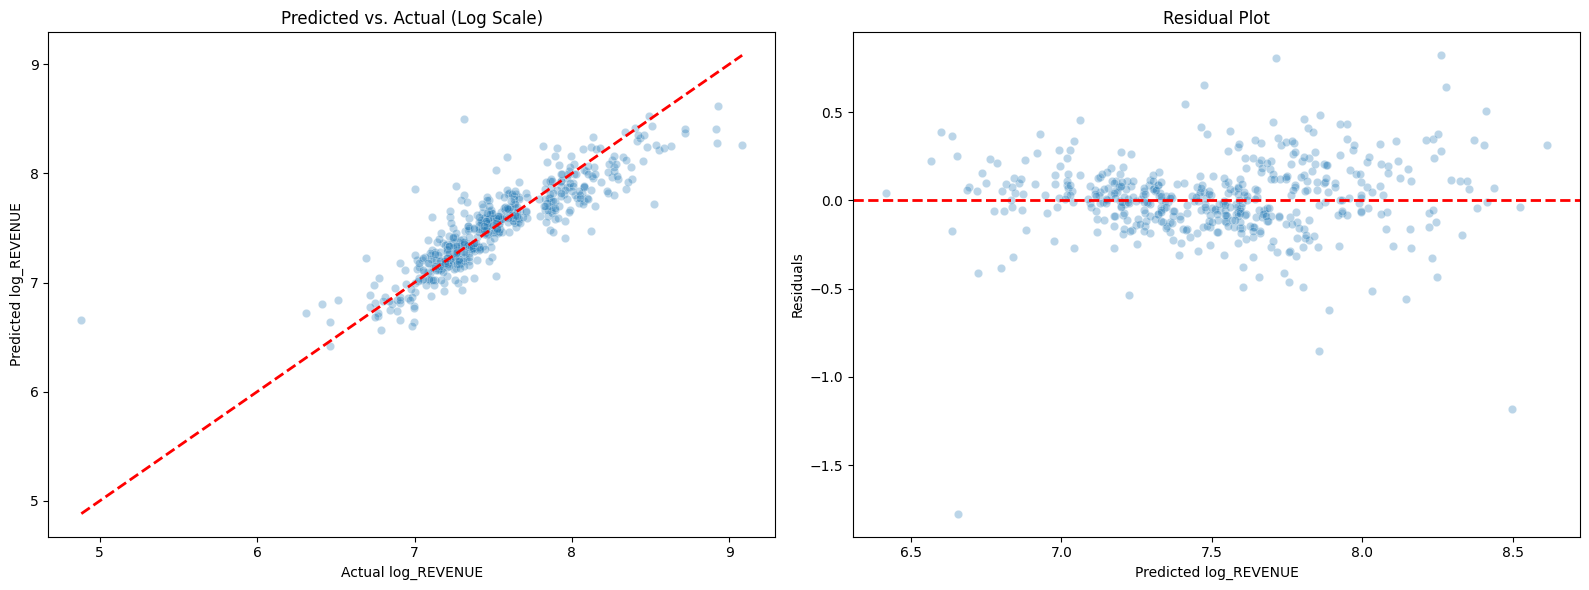

In [ ]:
# --- Visualizing Model Performance ---

# Assuming `avg_test_pred` from the previous cell is the blended prediction for the test set
# and `y_test` is the actual log_REVENUE values.
preds = avg_test_pred # Assign the correct prediction variable

# Calculating residuals
residuals = y_test - preds

# Create a figure with two subplots
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# 1. Predicted vs Actual Plot
sns.scatterplot(x=y_test, y=preds, ax=ax[0], alpha=0.3)
ax[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax[0].set_title('Predicted vs. Actual (Log Scale)')
ax[0].set_xlabel('Actual log_REVENUE')
ax[0].set_ylabel('Predicted log_REVENUE')

# 2. Residual Plot
sns.scatterplot(x=preds, y=residuals, ax=ax[1], alpha=0.3)
ax[1].axhline(y=0, color='r', linestyle='--', lw=2)
ax[1].set_title('Residual Plot')
ax[1].set_xlabel('Predicted log_REVENUE')
ax[1].set_ylabel('Residuals')

plt.tight_layout()
plt.show()

In [ ]:
def mape_score(model, x_test, y_test, transformer=None, verbose=True):
    """
    This function will produce mean absolute precision error (MAPE) results.
    If you transformed the y-variable before making predictions, make sure
    to use the transformer argument so that your results are evaluated fairly.


    PARAMETERS
    ----------
    model       | a fitted model object
    x_test      | x-data testing set
    y_test      | y-data testing set
    transformer | Use log if the y-variable was log transformed. Otherwise use an inverse transformer.
    verbose     | Whether to print MAPE results


    EXAMPLE USAGE
    -------------
    # no y-variable transformation while predicting
    mape_score(model  = my_model,
               x_test = x_test,
               y_test = y_test)


    # log_y transformation while predicting
    mape_score(model       = my_model,
               x_test      = x_test,
               y_test      = y_test,
               transformer = "log")


    # other y-transformation while predicting
    mape_score(model       = my_model,
               x_test      = x_test,
               y_test      = y_test,
               transformer = transformer)
    """
    preds  = model.predict(x_test, verbose=0).flatten()
    y_true = np.array(y_test).flatten()

    # inversing transformers
    if transformer:
        if transformer == 'log':
            y_true = np.exp(y_true)
            preds  = np.exp(preds)
        else:
            y_true = transformer.inverse_transform(y_true.reshape(-1, 1)).ravel()
            preds  = transformer.inverse_transform(preds.reshape(-1, 1)).ravel()

    indiv_mape     = np.abs((y_true - preds) / (y_true + 1e-8)) * 100
    overall_mape   = float(np.mean(indiv_mape))
    pct_within_20  = float(np.mean(indiv_mape < 20) * 100)

    # outputs
    if verbose == True:
        print(f"""
Overall MAPE: {overall_mape}

* Lower MAPE values are better.
            """)

    # returning results
    return {
        "overall_mape"  : round(overall_mape,  4)
}

In [ ]:
import numpy as np
from sklearn.metrics import r2_score

# Defining a wrapper class to make our blended predictions compatible with the mape_score function
class BlendedModelWrapper:
    def __init__(self, predictions):
        self.predictions = predictions

    def predict(self, x, verbose=0):
        return self.predictions

# Using the final_test_pred from the constrained blended model (cell 8543e1b8)
blended_wrapper = BlendedModelWrapper(final_test_pred)

# Executing the MAPE score for the final ensemble
final_mape = mape_score(model       = blended_wrapper,
                        x_test      = x_test,
                        y_test      = y_test,
                        transformer = 'log')

# Final Report Summary
print(f"""
Final Model Performance Report
------------------------------
Test R-Squared: {new_test_r2}
Test MAPE     : {final_mape['overall_mape']}%
""")


Overall MAPE: 16.259611258118294

* Lower MAPE values are better.
            

Final Model Performance Report
------------------------------
Test R-Squared: 0.7633
Test MAPE     : 16.2596% 



In [ ]:
import numpy as np

# Creating a wrapper for the unconstrained blended predictions (Variable: avg_test_pred)
unconstrained_wrapper = BlendedModelWrapper(avg_test_pred)

# Calculate MAPE and Hit Rate for the unconstrained model
unconstrained_results = mape_score(model       = unconstrained_wrapper,
                                  x_test      = x_test,
                                  y_test      = y_test,
                                  transformer = 'log',
                                  verbose     = False)

# Recalculating metrics for transparency
# Using indiv_mape logic from mape_score to get the hit rate specifically
y_true_orig = np.exp(y_test)
preds_orig = np.exp(avg_test_pred)
indiv_mape = np.abs((y_true_orig - preds_orig) / (y_true_orig)) * 100
hit_rate = np.mean(indiv_mape < 20) * 100

print(f"""
Unconstrained Blended Model Performance (Before Final Constraints)
--------------------------------------------------------------
Test R-Squared: {stack_score_test}
Test MAPE     : {unconstrained_results['overall_mape']}%
Hit Rate (Predictions within 20%): {hit_rate:.2f}%
""")


Unconstrained Blended Model Performance (Before Final Constraints)
--------------------------------------------------------------
Test R-Squared: 0.7721
Test MAPE     : 15.8683%
Hit Rate (Predictions within 20%): 75.56%

